# Optimal Brain Damage

Reproduction of **LeCun, Denker & Solla, "Optimal Brain Damage" (NIPS 1989)**,
plus a modern CIFAR-10 counterpart — and one experiment the paper didn't run.

The idea: after training, estimate how much the loss would increase if each
parameter were deleted, using a diagonal second-order Taylor expansion:

$$s_k = \tfrac{1}{2} h_{kk} w_k^2$$

where $h_{kk}$ is the diagonal of the Hessian (computed here with the paper's
Levenberg–Marquardt / Gauss-Newton approximation). Deleting the weights with
the *smallest saliency* $s_k$ should hurt less than deleting the weights with
the smallest *magnitude* — that comparison is the core result of the paper.

The `digits` experiment mirrors the paper: the 1989 zip-code conv net (16×16
input, ~8.8k free parameters) trained with MSE to ±1 targets. Since the
original zip code data isn't available we use MNIST downsampled to 16×16,
with the paper's dataset sizes (7,291 train / 2,007 test).

**Three questions**, in order:

1. Does the saliency ranking beat magnitude, as the paper claims? (§2–§4)
2. Does it still, on a modern over-parameterized net? (§5)
3. **How different are the two rankings in the first place?** $s_k$ and $w_k^2$
   are the *same ranking* whenever $h_{kk}$ is constant, so magnitude pruning
   isn't an approximation to OBD — it's OBD with an isotropic-curvature prior.
   §6 measures how far from constant $h_{kk}$ actually is, and where the
   difference lives.

## How to read this notebook

The code runs as a pipeline of five modules, each stage handing the next a file:

```
datasets.py     MNIST → 16×16, CIFAR-10, held in memory as single tensors
obd.py          config → device → models → training → Hessian / saliencies → pruning primitives
experiments.py  the sweeps, the prune-retrain loop, the overlap analysis (the --only registry)
figures.py      results JSON → matplotlib (no torch)
report.py       results JSON → the generated tables in RESULTS.md and the README
main.py         disk I/O + CLI

--train  → checkpoints/<name>.pt   --prune → results/<name>.json   --plot → figures/*.png
```

**This notebook reads cached results.** Nothing here trains or prunes. Each
section loads `results/<name>.json` and prints the command for anything that's
missing. `python3 main.py` regenerates everything, both datasets, and ends by
re-executing this notebook.

Each section opens with the live source of the function that produced its
numbers (`show(...)`, so it can't drift from the code), then the figure, then the
commentary. Every number in the commentary is read from the results. The
interpretive sentences around them were written against the run recorded in
each results file's `_meta` and are reviewed after every full run. The short
version is in [`RESULTS.md`](RESULTS.md).

**Configuration.** `Experiment` (in `obd.py`) is a frozen dataclass holding
everything that differs between the two setups: the loss (`"mse"` for the paper,
`"ce"` for the modern net), training hyperparameters and the pruning schedule.
`DIGITS` and `CIFAR` are the two presets, and `main.configure` applies `--set`
overrides with `dataclasses.replace`, so a preset is never mutated. `device="auto"`
resolves once, at the entry point, to Metal, then CUDA, then CPU. `SEED = 1989`
is set before training and before *each* pruning experiment, so a result doesn't
depend on which subset of experiments ran.

In [1]:
import inspect
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display

import figures
import main
from obd import count_free_parameters, evaluate

# resolve_device() picks Metal, else CUDA, else CPU. Pin it if you'd rather:
#     main.configure("digits", ["device=cpu"])
digits = main.configure("digits")
cifar = main.configure("cifar")
print(f"python {sys.executable}\ntorch {torch.__version__}   device: {digits.device}")


def load(exp, *needed):
    """Cached results for an experiment, with a recipe for anything missing."""
    try:
        results = main.load_results(exp)
    except FileNotFoundError as err:
        print(err)
        return {}
    main.check_meta(exp, results)
    missing = [key for key in needed if key not in results]
    if missing:
        print(f"missing {missing} — run:\n"
              f"    python3 main.py --dataset {exp.name} --only {' '.join(missing)}")
    return results


def have(results, *keys):
    """True when every named experiment is in the cache. Guards the commentary
    cells below, which read numbers straight out of it."""
    return all(key in results for key in keys)


def note(text):
    """Commentary whose numbers come from the loaded data, never from memory."""
    display(Markdown("\n".join("> " + line for line in text.strip().splitlines())))


def table(rows, headers=("", "")):
    body = "\n".join("| " + " | ".join(str(c) for c in row) + " |" for row in rows)
    return (f"| {' | '.join(headers)} |\n| {' | '.join('---' for _ in headers)} |\n"
            f"{body}")


def at(series, target):
    """The recorded point nearest `target` weights remaining."""
    return min(series, key=lambda p: abs(p["remaining"] - target))


def widest_gap(results, a, b, key="train_loss"):
    """Where two series differ most, and by how much."""
    left = {p["remaining"]: p[key] for p in results[a]}
    right = {p["remaining"]: p[key] for p in results[b]}
    shared = sorted(set(left) & set(right))
    n = max(shared, key=lambda k: abs(left[k] - right[k]))
    return n, left[n], right[n]


def show(obj, until=None):
    """The live source of a function or class — the code that produced the
    results below, not a copy of it. `until` cuts a long function off at the
    first line containing that text."""
    lines, start = inspect.getsourcelines(obj)
    if until is not None:
        cut = next(i for i, line in enumerate(lines) if until in line)
        lines = lines[:cut] + ["    ...\n"]
    where = f"{Path(inspect.getsourcefile(obj)).name}:{start}"
    display(Markdown(f"`{where}`\n```python\n{''.join(lines)}```"))


python /Users/jackblackburn/code/main/obd/.venv/bin/python
torch 2.13.0   device: mps


## 1. The paper's setup

16×16 grayscale digits, background −1, trained to ±1 targets.

`datasets.load` returns `((x_train, y_train, labels_train), (x_test, y_test,
labels_test))`. The convention: **`y` is whatever the loss consumes; `labels` are
always integer classes**, used for accuracy. For digits `y` is a ±1 one-hot matrix
(the paper trains tanh outputs with MSE to ±1 targets). For CIFAR, cross-entropy
consumes the integer labels directly, so `y` *is* `labels`. The zip-code data
isn't public, so MNIST is bilinearly downsampled to 16×16, rescaled to [−1, 1],
and cut to the paper's sizes.

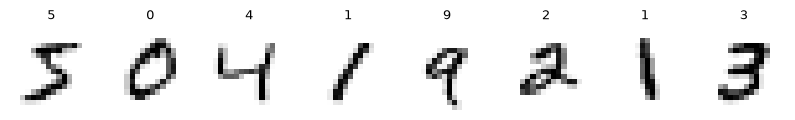

In [2]:
from datasets import load as load_data

(x_tr, y_tr, l_tr), (x_te, y_te, l_te) = load_data(digits)
fig, axes = plt.subplots(1, 8, figsize=(10, 1.6))
for ax, img, label in zip(axes, x_tr, l_tr):
    ax.imshow(img.squeeze(), cmap="gray_r")
    ax.set_title(int(label), fontsize=9)
    ax.axis("off")

## 2. The base network

The 1989 zip-code convnet: two stride-2 conv layers (the second with a fixed
sparse connection table, so each H2 map sees only 8 of the 12 H1 maps), then
two fully-connected layers, all with LeCun's scaled tanh $1.7159\tanh(2x/3)$.

Three details matter:

- **The scaled sigmoid** `1.7159·tanh(2x/3)` keeps the ±1 targets inside its linear
  range, so the net fits them without saturating. This matters for OBD: with a
  plain tanh, units saturate, the curvature collapses to ~0, and the saliency
  ranking becomes noise.
- **The sparse connection table** is enforced by multiplying `conv2.weight` by a
  fixed binary mask *in the forward pass*. The tensor keeps its full shape, which
  keeps the Hessian and pruning code uniform. The paper's exact table was never
  published, so map *j* reads maps *j..j+7* mod 12.
- **Padding with −1**, the background value, so the 5×5 stride-2 convs map 16→8→4.

In [3]:
from obd import MnistNet, sigmoid

show(sigmoid)
show(MnistNet)

`obd.py:74`
```python
def sigmoid(x):
    """LeCun's scaled tanh 1.7159 * tanh(2x/3): f(+-1) is well inside the
    linear range, so the net can fit +-1 targets without saturating. With a
    plain tanh the weights grow until every unit saturates, the curvature
    (and hence every OBD saliency) collapses to ~0, and the ranking becomes
    noise."""
    return 1.7159 * torch.tanh(2.0 / 3.0 * x)
```

`obd.py:94`
```python
class MnistNet(nn.Module):
    """The same architecture of (LeCun et al. 1989, "Backpropagation Applied
    to Handwritten Zip Code Recognition") adapted to MNIST:

        input   1 @ 16x16
        H1     12 @ 8x8    5x5 conv, stride 2
        H2     12 @ 4x4    5x5 conv, stride 2, each map sees only 8 of the
                           12 H1 maps (sparse connection table)
        H3     30          fully connected
        output 10          fully connected, tanh, trained to +-1 targets

    Free parameters: 312 + 2412 + 5790 + 310 = 8824
    """

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 12, kernel_size=5, stride=2)
        self.conv2 = nn.Conv2d(12, 12, kernel_size=5, stride=2)
        self.fc1 = nn.Linear(12 * 4 * 4, 30)
        self.fc2 = nn.Linear(30, 10)

        # fixed sparse connection table for H1 -> H2, broadcast to kernel shape
        mask = _connection_table()[:, :, None, None].expand(12, 12, 5, 5)
        self.register_buffer("conn_mask", mask.clone())

    def forward(self, x):
        # pad with -1 (the background value) so 5x5/stride-2 convs map 16->8->4
        x = F.pad(x, (2, 2, 2, 2), value=-1.0)
        x = sigmoid(self.conv1(x))
        x = F.pad(x, (2, 2, 2, 2), value=-1.0)
        x = sigmoid(F.conv2d(x, self.conv2.weight * self.conn_mask,
                             self.conv2.bias, stride=2))
        x = x.flatten(1)
        x = sigmoid(self.fc1(x))
        x = sigmoid(self.fc2(x))
        return x
```

Training (`obd.train`) is plain Adam over shuffled slices, with two
non-obvious points. **Weight decay is not cosmetic.** Without it, redundant large
weights sit in flat directions where the quadratic saliency estimate breaks down,
and §6 gives it a second job. **Pruning is enforced by masks, not by removing
weights.** A mask is a `{param_name: 0/1 tensor}` dict, reapplied after *every*
optimizer step so pruned weights stay at zero. `evaluate` normalizes its summed
loss to match the mean-reduced training loss exactly, which matters because OBD's
*predicted* loss increases have to be on the same scale as the measured ones.

Run `python3 main.py --dataset digits --train` if there's no checkpoint yet.

In [4]:
splits = [tuple(t.to(digits.device) for t in s)
          for s in ((x_tr, y_tr, l_tr), (x_te, y_te, l_te))]
try:
    net = main.load_base_model(digits)
except FileNotFoundError:
    net = None
    print("no checkpoint — run:\n    python3 main.py --dataset digits --train")

if net is not None:
    metrics = {name: evaluate(net, *split, digits.loss)
               for name, split in zip(("train", "test"), splits)}
    note(f"""
**Base model** — {count_free_parameters(net):,} free parameters, trained for
{digits.epochs} epochs with weight decay {digits.weight_decay:g}.

{table([(k, f"{v[0]:.4f}", f"{v[1]:.1%}") for k, v in metrics.items()],
       ("split", "MSE", "accuracy"))}

The train–test gap is what the paper's regime looks like: ~8.8k free parameters
for 7,291 examples is close to the data, not far above it. That matters for
everything below — OBD's premise is that the network is at a well-conditioned
minimum with little slack, which is exactly the regime §5 leaves behind.
""")

> **Base model** — 8,824 free parameters, trained for
> 60 epochs with weight decay 0.001.
> 
> | split | MSE | accuracy |
> | --- | --- | --- |
> | train | 0.0244 | 98.1% |
> | test | 0.0435 | 95.1% |
> 
> The train–test gap is what the paper's regime looks like: ~8.8k free parameters
> for 7,291 examples is close to the data, not far above it. That matters for
> everything below — OBD's premise is that the network is at a well-conditioned
> minimum with little slack, which is exactly the regime §5 leaves behind.

## 3. Deleting weights without retraining — paper Fig. 2

Rank the trained network's weights once, delete progressively more of them, and
measure the loss. No retraining, so this isolates the ranking itself.

Three rules, which differ *only* in how much they let the curvature vary:

| rule | score | assumption about $h$ |
|---|---|---|
| magnitude | $w^2$ | constant everywhere |
| layer-mean saliency | $\tfrac12 \bar h_L w^2$ | constant within each layer |
| OBD saliency | $\tfrac12 h_{kk} w^2$ | the full diagonal |

Dashed = ranked once on the trained net. Solid = re-ranked after every
deletion. The distinction is the point: the saliency is a *local* estimate, so
a ranking computed at the full network goes stale as weights disappear.

### The code: saliency and ranking

The saliency is the diagonal second-order Taylor estimate of the loss increase
from deleting $w_k$. The paper computes $h_{kk}$ with the Levenberg–Marquardt
approximation, which is exactly the **Gauss-Newton diagonal**:
$h_{kk} = \sum_{\text{samples}} [J^\top H_{out} J]_{kk}$, where $J$ is the
Jacobian of the network outputs and $H_{out}$ the loss's Hessian with respect to them.
For MSE, $H_{out}$ is a constant diagonal, so $h_{kk}$ is a sum of squared
output-Jacobian entries. For softmax cross-entropy, $H_{out} = \mathrm{diag}(p) - pp^\top$,
which gives the variance-like form in the two `einsum`s. Both are non-negative, which
is what lets §6 take logarithms.

Instead of the paper's hand-written second-order backprop, the per-sample
Jacobians come from `torch.func`: `vmap(jacrev(outputs))`, one
`(batch, outputs, *param_shape)` tensor per parameter. Only prunable weights are
differentiated, and both branches scale $h$ to the *mean*-reduced loss.

In [5]:
from obd import _hessian_pass, saliencies, scores_for, prune_to

show(_hessian_pass)
show(saliencies)

`obd.py:256`
```python
def _hessian_pass(model, x, params, buffers, loss, batch_size, n_outputs):
    """Accumulate the Gauss-Newton diagonal over x, differentiating only
    w.r.t. `params` (the rest of the model's parameters are held fixed)."""
    fixed = {name: p.detach() for name, p in model.named_parameters()
             if name not in params}

    def outputs(diff_params, x_single):
        merged = {**fixed, **diff_params}
        return functional_call(model, (merged, buffers),
                               (x_single.unsqueeze(0),)).squeeze(0)

    # per-sample Jacobian of the network outputs w.r.t. every diff parameter
    jac_fn = vmap(jacrev(outputs), in_dims=(None, 0))

    h = {name: torch.zeros_like(p) for name, p in params.items()}
    for i in range(0, len(x), batch_size):
        batch = x[i:i + batch_size]
        jac = jac_fn(params, batch)  # name -> (B, O, *param.shape)
        if loss == "mse":
            for name in h:
                h[name] += 2.0 * jac[name].pow(2).sum(dim=(0, 1))
        elif loss == "ce":
            with torch.no_grad():
                p = model(batch).softmax(dim=1)  # (B, O)
            for name in h:
                J = jac[name].flatten(2)                        # (B, O, K)
                mean = torch.einsum("bo,bok->bk", p, J)          # sum_o p_o J_ok
                hk = torch.einsum("bo,bok->k", p, J.pow(2)) - mean.pow(2).sum(0)
                h[name] += hk.view_as(h[name])
        else:
            raise ValueError(loss)

    scale = 1.0 / (len(x) * n_outputs) if loss == "mse" else 1.0 / len(x)
    return {name: value * scale for name, value in h.items()}
```

`obd.py:337`
```python
def saliencies(model, x, loss="mse", max_samples=None, names=None):
    """OBD saliency s_k = 1/2 * h_kk * w_k^2, for `names` (default: all)."""
    params = dict(model.named_parameters())
    names = list(params) if names is None else list(names)
    h = diagonal_hessian(model, x, loss=loss, max_samples=max_samples, names=names)
    return {name: 0.5 * h[name] * params[name].detach() ** 2 for name in names}
```

Only conv/linear *weights* are prunable (biases excluded), and connection-table
zeros are never counted. To rank globally across layers, the per-tensor dicts are
flattened into one vector. `scores_for` implements the three rules in the table
above, and `prune_to` keeps the top *n* by score. Already-dead weights get score
$+\infty$, so they can never be resurrected.

In [6]:
show(scores_for)
show(prune_to)

`obd.py:396`
```python
def scores_for(model, x_train, rank_by, exp):
    """Per-weight deletion scores. Higher score = more worth keeping."""
    names = prunable_names(model)
    params = dict(model.named_parameters())
    if rank_by == "magnitude":
        return {name: params[name].detach().abs() for name in names}
    if rank_by == "saliency":
        return saliencies(model, x_train, loss=exp.loss,
                          max_samples=exp.hessian_samples, names=names)
    if rank_by == "saliency_layermean":
        h = diagonal_hessian(model, x_train, loss=exp.loss,
                             max_samples=exp.hessian_samples, names=names)
        return {name: 0.5 * h[name].mean() * params[name].detach() ** 2
                for name in names}
    raise ValueError(f"unknown ranking {rank_by!r}; choose from {list(RANKINGS)}")
```

`obd.py:413`
```python
def prune_to(masks, scores, n_remaining, names):
    """Return new masks with only the n_remaining highest-scored weights kept."""
    mask_flat = flatten(masks, names).clone()
    score_flat = flatten(scores, names).clone()
    score_flat[mask_flat == 0] = float("inf")  # already-dead weights stay dead
    n_delete = int(mask_flat.sum().item()) - n_remaining
    if n_delete > 0:
        order = torch.argsort(score_flat)
        mask_flat[order[:n_delete]] = 0.0
    return unflatten(mask_flat, masks, names)
```

### The sweep

`sweep_no_retrain` deletes down to log-spaced targets (log-spaced because nothing
happens between 100% and 80% remaining, and everything happens in the last
decade). It either ranks once on the trained net or re-ranks on the pruned net
before each further deletion. For the saliency rules it also accumulates
`predicted_increase` (the sum of deleted saliencies, OBD's forecast) next to the
measured `actual_increase`, which is the data behind Fig 3.

In [7]:
from experiments import sweep_no_retrain, iterative_prune_retrain, overlap_analysis

show(sweep_no_retrain)

`experiments.py:66`
```python
def sweep_no_retrain(model, splits, rank_by, exp, recompute=False):
    """Delete increasing numbers of weights without retraining (Figs 2, 3).

    With recompute=False the ranking is computed once on the trained net.
    With recompute=True the scores are recomputed on the pruned net before
    each further deletion - still no retraining. The distinction matters:
    the saliency is a local second-order estimate, so a ranking computed at
    the full network goes stale as weights are deleted. (Magnitude ranking is
    unaffected - deletion doesn't change the surviving |w|.)
    """
    x_tr = splits[0][0]
    label = rank_by + ("-recomputed" if recompute else "")
    pruned, names, masks, n_total = _setup(model, exp)
    scores = scores_for(pruned, x_tr, rank_by, exp)

    base = _point(model, splits, exp, n_total)
    results = [base]
    predicted = 0.0
    for n_remaining in sweep_targets(n_total, exp):
        if recompute and len(results) > 1:
            scores = scores_for(pruned, x_tr, rank_by, exp)
        before = flatten(masks, names) > 0
        masks = prune_to(masks, scores, n_remaining, names)
        newly_deleted = before & (flatten(masks, names) == 0)
        if rank_by.startswith("saliency"):
            # the second-order forecast of the damage: sum of deleted saliencies
            predicted += flatten(scores, names)[newly_deleted].sum().item()
        apply_masks(pruned, masks)

        point = _point(pruned, splits, exp, n_remaining)
        if rank_by.startswith("saliency"):
            point["predicted_increase"] = predicted
            point["actual_increase"] = point["train_loss"] - base["train_loss"]
        results.append(point)
        print(f"  [{label}] {n_remaining:7d} weights left  "
              f"train loss {point['train_loss']:.4f}")
    return results
```

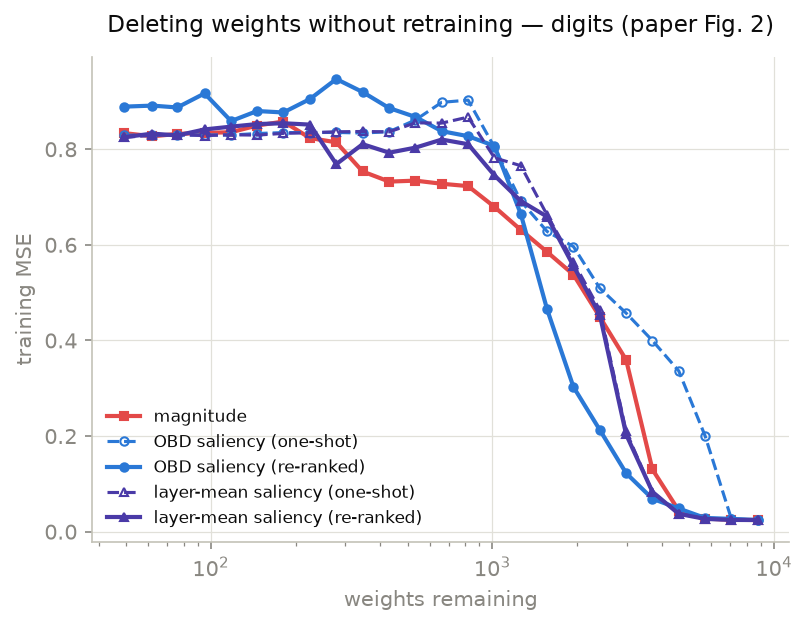

In [8]:
dr = load(digits, "magnitude", "saliency", "saliency_recomputed",
          "saliency_layermean_recomputed", "retrain", "retrain_magnitude", "overlap")
figures.fig2_magnitude_vs_obd(dr, digits);

In [9]:
if have(dr, "magnitude", "saliency", "saliency_recomputed", "overlap"):
    n, mag, sal = widest_gap(dr, "magnitude", "saliency_recomputed")
    n1, mag1, one = widest_gap(dr, "magnitude", "saliency")
    note(f"""
**Fig 2.** Re-ranking is what reproduces the paper. At its widest, re-ranked
saliency deletion sits at train MSE **{sal:.3f}** where magnitude is at
**{mag:.3f}** ({n:,} weights left, {1 - n / dr['overlap']['n_prunable']:.0%}
deleted).

The one-shot ranking (dashed blue) goes the *other* way — at its own worst
point it is at **{one:.3f}** against magnitude's **{mag1:.3f}** ({n1:,} left).
A saliency computed at the full network says nothing reliable about a network
with thousands of weights already gone: the lowest-saliency set contains large
weights sitting in flat directions, and deleting them all at once is far
outside the quadratic approximation's radius.

Notice where the violet layer-mean control falls. That's §6's subject.
""")

> **Fig 2.** Re-ranking is what reproduces the paper. At its widest, re-ranked
> saliency deletion sits at train MSE **0.122** where magnitude is at
> **0.360** (2,986 weights left, 66%
> deleted).
> 
> The one-shot ranking (dashed blue) goes the *other* way — at its own worst
> point it is at **0.336** against magnitude's **0.044** (4,592 left).
> A saliency computed at the full network says nothing reliable about a network
> with thousands of weights already gone: the lowest-saliency set contains large
> weights sitting in flat directions, and deleting them all at once is far
> outside the quadratic approximation's radius.
> 
> Notice where the violet layer-mean control falls. That's §6's subject.

### The forecast itself — paper Fig. 3

OBD doesn't just rank; it *predicts a number*. The saliency is an estimate of
the loss increase from deleting a weight, so the sum of the deleted saliencies
should equal the measured increase in loss. Both axes are on the same scale
(the Hessian is normalized to the mean-reduced loss), so `y = x` means the
Taylor expansion was exactly right.

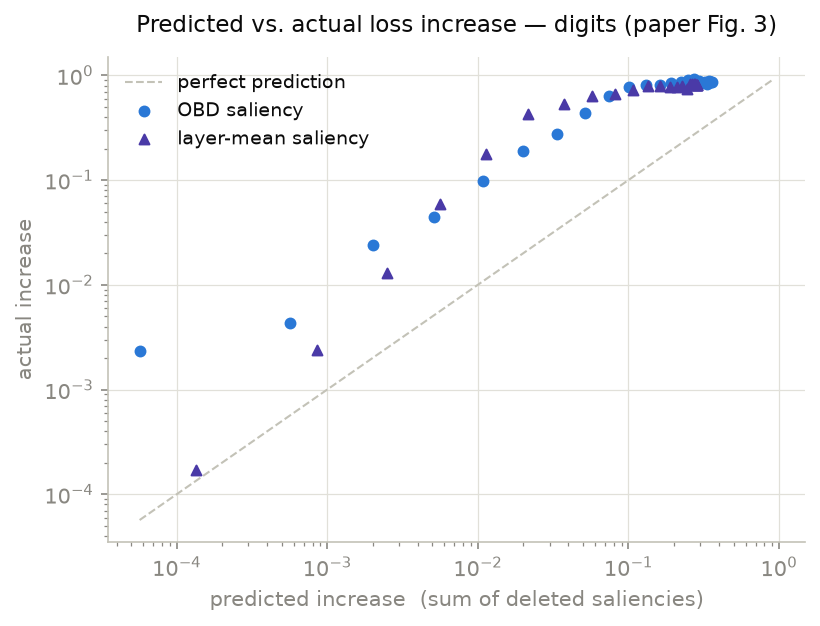

In [10]:
figures.fig3_predicted_vs_actual(dr, digits);

In [11]:
pts = [(p["predicted_increase"], p["actual_increase"])
       for p in dr.get("saliency_recomputed", []) if p.get("predicted_increase", 0) > 0]
if pts:
    ratios = sorted(a / p for p, a in pts)
    note(f"""
**Fig 3.** Monotone and roughly parallel to $y = x$ on log–log, but
systematically off: the measured damage is **{ratios[len(ratios) // 2]:.1f}×**
the forecast at the median point, ranging {ratios[0]:.1f}×–{ratios[-1]:.1f}×.

The prediction is a *useful ordering* and a *bad absolute estimate*. Two
reasons, both structural: the diagonal approximation drops every off-diagonal
$h_{{jk}}$, so it cannot see that deleting two weights together costs more than
deleting each alone; and the expansion is quadratic around the trained weights,
while these deletion steps move thousands of coordinates to zero at once.
""")

> **Fig 3.** Monotone and roughly parallel to $y = x$ on log–log, but
> systematically off: the measured damage is **5.0×**
> the forecast at the median point, ranging 2.4×–41.0×.
> 
> The prediction is a *useful ordering* and a *bad absolute estimate*. Two
> reasons, both structural: the diagonal approximation drops every off-diagonal
> $h_{jk}$, so it cannot see that deleting two weights together costs more than
> deleting each alone; and the expansion is quadratic around the trained weights,
> while these deletion steps move thousands of coordinates to zero at once.

## 4. The full loop: prune, retrain, repeat — paper Fig. 4

With a little retraining after each deletion round, the network can recover
from damage the previous figure showed as catastrophic.

The red control is the part that makes this honest. It runs the *identical*
loop — same schedule, same retraining budget — ranked by $|w|$. Without it, any
"we removed 80% of the network" headline is unattributable: it could be the
second-order ranking, or it could be that prune-a-little-retrain-a-little works
regardless of how you choose what to cut.

In [12]:
show(iterative_prune_retrain)

`experiments.py:109`
```python
def iterative_prune_retrain(model, splits, exp, rank_by="saliency"):
    """Prune, retrain, repeat (Fig 4).

    rank_by="saliency" is OBD proper; rank_by="magnitude" is the control
    that isolates how much of Fig 4's result is the saliency ranking and
    how much is just prune-a-little-retrain-a-little.
    """
    x_tr, y_tr = splits[0][0], splits[0][1]
    model, names, masks, n_remaining = _setup(model, exp)

    results = []
    while n_remaining >= exp.retrain_min_remaining:
        point = _point(model, splits, exp, n_remaining)
        results.append(point)
        print(f"  [retrain-{rank_by}] {n_remaining:7d} weights left  "
              f"train loss {point['train_loss']:.4f}  "
              f"test loss {point['test_loss']:.4f}  test acc {point['test_acc']:.3f}")

        n_remaining = int(n_remaining * exp.shrink)
        scores = scores_for(model, x_tr, rank_by, exp)
        masks = prune_to(masks, scores, n_remaining, names)
        apply_masks(model, masks)
        train(model, x_tr, y_tr, exp, epochs=exp.retrain_epochs, masks=masks)
    return results
```

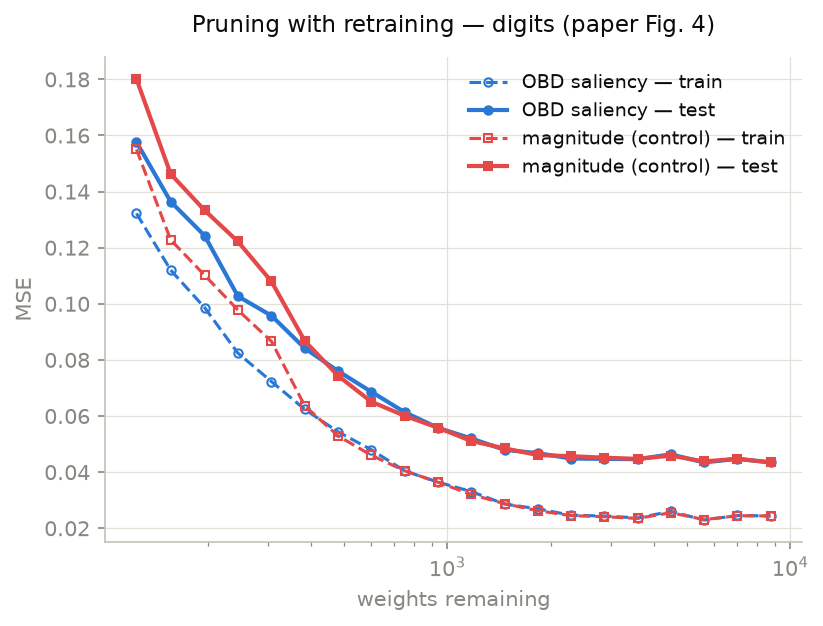

In [13]:
figures.fig4_retraining(dr, digits);

In [14]:
if have(dr, "retrain", "retrain_magnitude"):
    obd_pts = sorted(dr["retrain"], key=lambda p: -p["remaining"])
    mag_pts = sorted(dr["retrain_magnitude"], key=lambda p: -p["remaining"])
    base = obd_pts[0]
    survives = [p for p in obd_pts if p["test_acc"] >= base["test_acc"] - 0.005][-1]
    tail_obd, tail_mag = obd_pts[-1], mag_pts[-1]
    note(f"""
**Fig 4.** Retraining changes the picture completely. Test accuracy holds at
**{survives['test_acc']:.1%}** (base: {base['test_acc']:.1%}) down to
**{survives['remaining']:,}** weights — {1 - survives['remaining'] / base['remaining']:.0%}
of the network gone with no measurable cost.

But look at the control. Down to that point the two curves are on top of each
other; the saliency ranking earns nothing. Only in the extreme tail does a gap
open: at {tail_obd['remaining']:,} weights left, OBD holds
**{tail_obd['test_acc']:.1%}** against magnitude's **{tail_mag['test_acc']:.1%}**.

That is the honest version of the paper's result, and it is a narrower claim
than "OBD beats magnitude": *the second-order ranking matters once the network
has no slack left.* Everywhere above that, the procedure — not the criterion —
is doing the work.
""")

> **Fig 4.** Retraining changes the picture completely. Test accuracy holds at
> **94.6%** (base: 95.1%) down to
> **1,468** weights — 83%
> of the network gone with no measurable cost.
> 
> But look at the control. Down to that point the two curves are on top of each
> other; the saliency ranking earns nothing. Only in the extreme tail does a gap
> open: at 124 weights left, OBD holds
> **79.0%** against magnitude's **73.6%**.
> 
> That is the honest version of the paper's result, and it is a narrower claim
> than "OBD beats magnitude": *the second-order ranking matters once the network
> has no slack left.* Everywhere above that, the procedure — not the criterion —
> is doing the work.

## 5. A modern counterpart: CIFAR-10

The same experiments on a conventional VGG-style ReLU convnet (~590k
parameters) trained with cross-entropy. This is the regime the paper never saw:
heavily over-parameterized, ReLU rather than a scaled tanh, and a minimum that
is nothing like well-conditioned.

Generate with `python3 main.py --dataset cifar`.

  note: results/cifar.json predates provenance tracking — rerun the prune stage if in doubt
missing ['overlap'] — run:
    python3 main.py --dataset cifar --only overlap


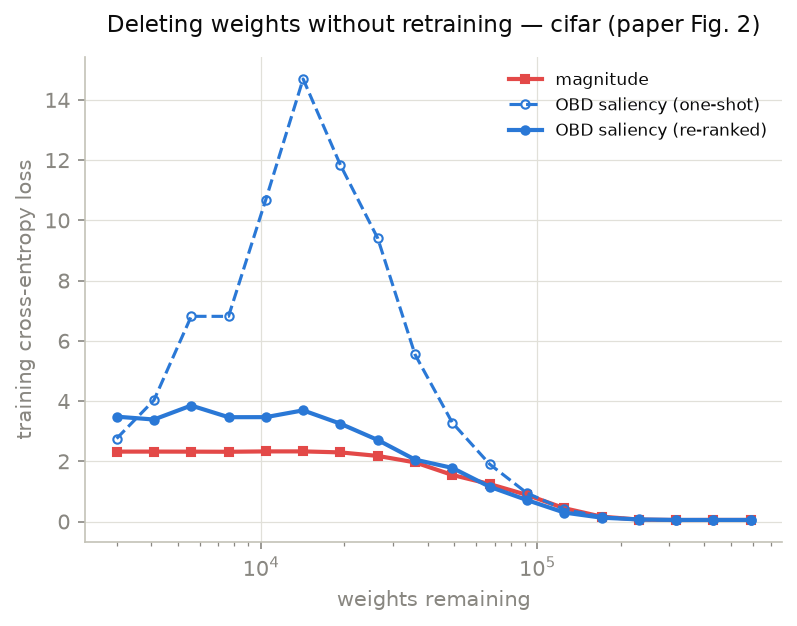

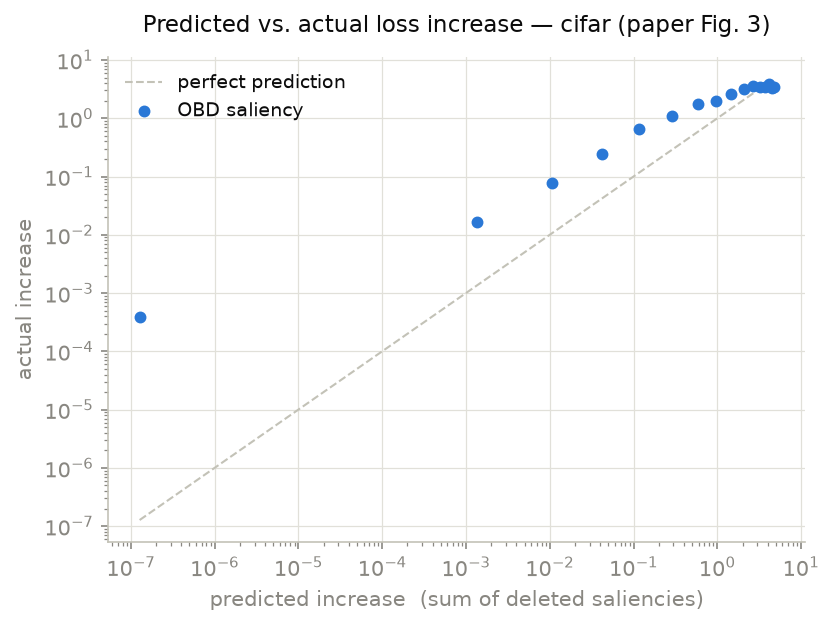

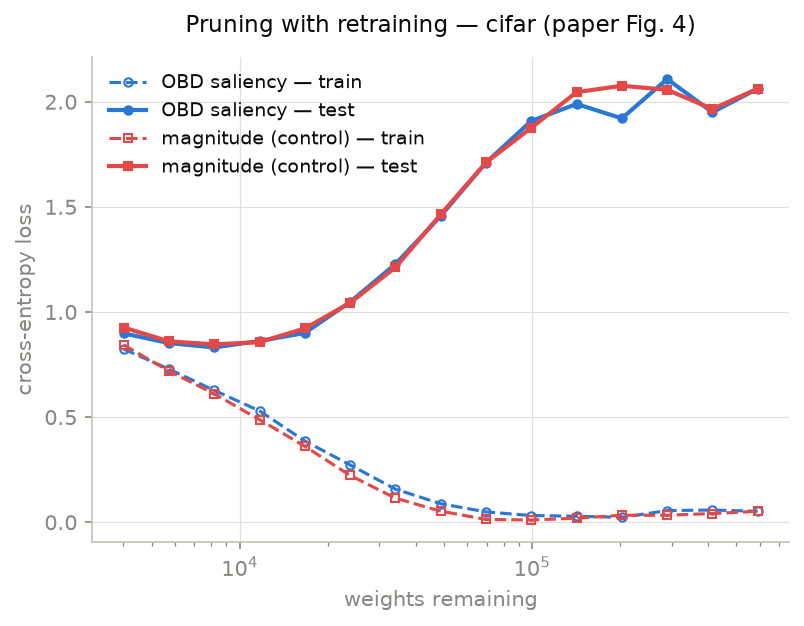

In [15]:
cr = load(cifar, "magnitude", "saliency", "saliency_recomputed", "overlap")
if cr:
    figures.fig2_magnitude_vs_obd(cr, cifar)
    figures.fig3_predicted_vs_actual(cr, cifar)
    figures.fig4_retraining(cr, cifar);

In [16]:
cpts = [(p["predicted_increase"], p["actual_increase"])
        for p in cr.get("saliency_recomputed", []) if p.get("predicted_increase", 0) > 0]
if have(cr, "retrain") and cpts:
    cbase = sorted(cr["retrain"], key=lambda p: -p["remaining"])[0]
    csurv = [p for p in sorted(cr["retrain"], key=lambda p: -p["remaining"])
             if p["test_acc"] >= cbase["test_acc"] - 0.005][-1]
    cratios = sorted(a / p for p, a in cpts)
    note(f"""
**CIFAR-10.** Base: {cbase['train_acc']:.1%} train / {cbase['test_acc']:.1%}
test — a heavily over-fit network, the opposite regime from digits.

- **Fig 2**: the staleness lesson survives the change of regime — re-ranking
  still beats the one-shot ranking. That part is about the *estimator*, and it
  travels.
- **Fig 3**: the forecast degrades further, under-predicting the damage by a
  median **{cratios[len(cratios) // 2]:.1f}×**. A ReLU network's loss surface is
  piecewise-linear; a quadratic model around the minimum has less to work with.
- **Fig 4**: {1 - csurv['remaining'] / cbase['remaining']:.1%} of the weights go
  with no accuracy cost — and the magnitude control tracks OBD the whole way.
  The headline is real; the attribution to second-order information is not.

This is the modern pruning literature's central finding in miniature: a
properly-tuned magnitude baseline is very hard to beat, and most published wins
don't clear it (Blalock et al. 2020, see References). Which raises the obvious
question — how different are these two rankings, actually?
""")

> **CIFAR-10.** Base: 98.2% train / 72.1%
> test — a heavily over-fit network, the opposite regime from digits.
> 
> - **Fig 2**: the staleness lesson survives the change of regime — re-ranking
>   still beats the one-shot ranking. That part is about the *estimator*, and it
>   travels.
> - **Fig 3**: the forecast degrades further, under-predicting the damage by a
>   median **2.1×**. A ReLU network's loss surface is
>   piecewise-linear; a quadratic model around the minimum has less to work with.
> - **Fig 4**: 98.6% of the weights go
>   with no accuracy cost — and the magnitude control tracks OBD the whole way.
>   The headline is real; the attribution to second-order information is not.
> 
> This is the modern pruning literature's central finding in miniature: a
> properly-tuned magnitude baseline is very hard to beat, and most published wins
> don't clear it (Blalock et al. 2020, see References). Which raises the obvious
> question — how different are these two rankings, actually?

## 6. Does OBD just rediscover magnitude?

Every figure so far treats "OBD saliency" and "magnitude" as two different
methods that happen to perform similarly. But look at the definition again:

$$s_k = \tfrac{1}{2} h_{kk} w_k^2$$

Global magnitude pruning ranks by $w_k^2$. So the two orderings are
**identical** whenever $h_{kk}$ is constant across $k$. Magnitude pruning is not
a cheap approximation to OBD — it is OBD under an isotropic-curvature prior. The
only question is how far from constant $h_{kk}$ really is.

In logs the saliency separates additively:

$$\log s_k = 2\log|w_k| + \log(h_{kk}/2)$$

so with variances $\sigma_w^2, \sigma_h^2$ and covariance $\sigma_{hw}$,

$$\operatorname{corr}(\log s, \log|w|) =
\frac{2\sigma_w^2 + \sigma_{hw}}
     {\sigma_w\sqrt{4\sigma_w^2 + \sigma_h^2 + 4\sigma_{hw}}}$$

Agreement is high whenever $\sigma_h \ll 2\sigma_w$, and positive covariance
raises it further. Four things follow, stated as predictions before the data:

1. **The rankings should overlap far above chance**, since the magnitude term
   enters with a factor of 2 and the curvature term with 1.
2. **$\sigma_h$ should be small *within* a layer.** For a weight $W_{ij}$,
   $\partial\,\text{out}_o/\partial W_{ij} = (\partial\,\text{out}_o/\partial a_i)\,x_j$,
   so the Gauss-Newton diagonal factorizes as
   $h_{ij} \approx \mathbb{E}[x_j^2]\cdot\mathbb{E}[\delta_i^2] = u_i v_j$ —
   **rank-one** across the weight matrix. Curvature should therefore act as a
   per-layer *offset*, not per-weight noise.
3. **So the two rankings should differ mainly in how they split the pruning
   budget across layers**, not in which weights they pick inside one.
4. **Weight decay should align them.** At a stationary point of
   $E + \tfrac{\lambda}{2}\|w\|^2$ the quadratic model gives
   $w_k = \frac{h_{kk}}{h_{kk}+\lambda} w_k^\ast$: low-curvature coordinates get
   shrunk toward zero, high-curvature ones don't. Weight decay *induces*
   $\sigma_{hw} > 0$ — it makes a small weight a symptom of low curvature. So
   digits ($\lambda = 10^{-3}$) should show a stronger effect than CIFAR
   ($\lambda = 10^{-4}$).

Prediction 1 first.

### The code: the overlap analysis

Everything is computed once, at the trained weights, over the *live* prunable
entries, in float64 on CPU. Weights or curvatures that are exactly zero have no
logarithm, so they are excluded from the log-space statistics and counted in
`n_dropped_zero`. `predicted_pearson` evaluates the identity above from the
moments; it must match the directly measured `pearson_log`, which checks that
the decomposition is computed on what it claims. Rank correlations are done in
torch (argsort twice, then Pearson on the ranks). Kendall's τ is O(n²), so it runs
on a fixed 2,048-weight subsample, while Spearman is exact. The rest of the
function builds the curves behind Figs 5–7.

In [17]:
show(overlap_analysis, until="spearman_gaussian")

`experiments.py:220`
```python
def overlap_analysis(model, splits, exp):
    """Compare the OBD and magnitude rankings of the trained network.

    Everything is computed once, at the trained weights, over the live
    prunable entries (structurally absent connection-table entries excluded).
    """
    x_tr = splits[0][0]
    names = prunable_names(model)
    params = dict(model.named_parameters())
    masks = initial_masks(model)

    print("  [overlap] computing the diagonal Hessian...")
    h_by_name = diagonal_hessian(model, x_tr, loss=exp.loss,
                                 max_samples=exp.hessian_samples, names=names)

    live = (flatten(masks, names) > 0).cpu()
    layer = _layer_index(masks, names)[live]
    w = flatten({n: params[n].detach().abs() for n in names}, names).cpu().double()[live]
    h = flatten(h_by_name, names).cpu().double()[live]
    s = 0.5 * h * w.pow(2)
    n_total = int(live.sum().item())

    # log-space statistics need strictly positive entries; a dead ReLU path or
    # an exactly-zero weight has no logarithm and is reported, not silently kept
    ok = (w > 0) & (h > 0)
    n_dropped = int((~ok).sum().item())
    log_w, log_h, log_s = w[ok].log(), h[ok].log(), s[ok].log()
    layer_ok = layer[ok]

    var_w = float(log_w.var(unbiased=False))
    var_h = float(log_h.var(unbiased=False))
    cov = float(((log_h - log_h.mean()) * (log_w - log_w.mean())).mean())
    # the identity above, evaluated from the moments; must match pearson_log
    var_s = 4 * var_w + var_h + 4 * cov
    predicted = ((2 * var_w + cov) / math.sqrt(var_w * var_s)
                 if var_w > 0 and var_s > 0 else float("nan"))

    pearson_log = _pearson(log_s, log_w)
    spearman = _spearman(s, w)
    # what the rank correlation would be if (log h, log|w|) were jointly
    # Gaussian; the gap to `spearman` is a measure of how heavy the tails are
    gaussian_estimate = (6.0 / math.pi) * math.asin(max(-1.0, min(1.0, pearson_log)) / 2.0)

    # where does the curvature variance live: between layers, or within them?
    layer_means = torch.stack([log_h[layer_ok == i].mean()
                               for i in range(len(names))
                               if int((layer_ok == i).sum()) > 0])
    layer_sizes = torch.tensor([float((layer_ok == i).sum())
                                for i in range(len(names))
                                if int((layer_ok == i).sum()) > 0], dtype=torch.double)
    grand = (layer_means * layer_sizes).sum() / layer_sizes.sum()
    between = float((layer_sizes * (layer_means - grand).pow(2)).sum() / layer_sizes.sum())

    per_layer = []
    for i, name in enumerate(names):
        sel = layer == i
        sel_ok = layer_ok == i
        if int(sel.sum()) == 0:
            continue
        per_layer.append({
            "name": name,
            "n": int(sel.sum().item()),
            "spearman_within": _spearman(s[sel], w[sel]),
            "log_h_mean": float(log_h[sel_ok].mean()) if int(sel_ok.sum()) else float("nan"),
            "log_h_std": float(log_h[sel_ok].std(unbiased=False)) if int(sel_ok.sum()) > 1 else 0.0,
            "log_w_std": float(log_w[sel_ok].std(unbiased=False)) if int(sel_ok.sum()) > 1 else 0.0,
            "h_median": float(h[sel].median()),
        })

    # how much of each ranking's kept set is shared, at every pruning level
    overlap_curve, allocation = [], []
    for n_remaining in [n_total] + sweep_targets(n_total, exp):
        keep_obd = keep_mask(s, n_remaining)
        keep_mag = keep_mask(w, n_remaining)
        shared = int((keep_obd & keep_mag).sum().item())
        union = int((keep_obd | keep_mag).sum().item())
        dead_shared = int((~keep_obd & ~keep_mag).sum().item())
        dead_union = int((~keep_obd | ~keep_mag).sum().item())
        overlap_curve.append({
            "remaining": n_remaining,
            "overlap_frac": shared / n_remaining,
            "jaccard_kept": shared / union if union else float("nan"),
            "jaccard_pruned": dead_shared / dead_union if dead_union else float("nan"),
            "chance": n_remaining / n_total,
        })
        allocation.append({
            "remaining": n_remaining,
            "kept_obd": {names[i]: int((keep_obd & (layer == i)).sum().item())
                         for i in range(len(names))},
            "kept_mag": {names[i]: int((keep_mag & (layer == i)).sum().item())
                         for i in range(len(names))},
            "layer_size": {names[i]: int((layer == i).sum().item())
                           for i in range(len(names))},
        })
        print(f"  [overlap] {n_remaining:7d} weights left  "
              f"shared {shared / n_remaining:.3f}  (chance {n_remaining / n_total:.3f})")

    generator = torch.Generator().manual_seed(0)
    kendall = _kendall_subsample(s, w, generator)
    pick = torch.randperm(int(ok.sum().item()), generator=generator)[:SCATTER_POINTS]

    return _json_safe({
        "n_prunable": n_total,
        "n_dropped_zero": n_dropped,
        "layers": names,
        "global": {
            "spearman": spearman,
    ...
```

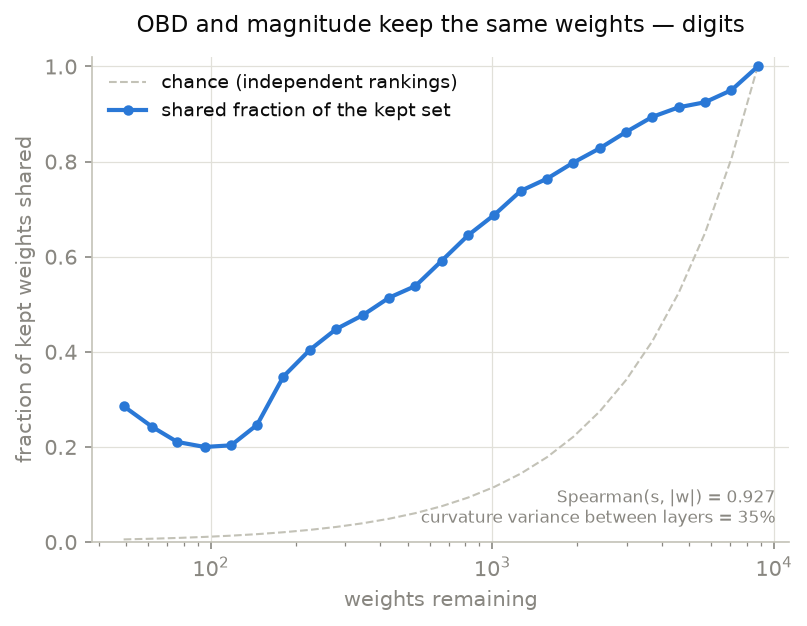

In [18]:
figures.fig5_overlap(dr, digits);

In [19]:
if have(dr, "overlap"):
    g = dr["overlap"]["global"]
    tenth = at(dr["overlap"]["overlap_curve"], dr["overlap"]["n_prunable"] // 10)
    note(f"""
**Prediction 1 holds, and not narrowly.** At {tenth['remaining']:,} weights
remaining the two rankings keep **{tenth['overlap_frac']:.0%}** of the same
weights, where independent rankings would share {tenth['chance']:.1%}.

{table([("Spearman(s, |w|)", f"{g['spearman']:.3f}"),
        ("Kendall τ (subsample)", f"{g['kendall_subsample']:.3f}"),
        ("corr(log s, log|w|)", f"{g['pearson_log']:.3f}"),
        ("— same, from the moments", f"{g['predicted_pearson']:.3f}"),
        ("Var(log h)", f"{g['var_log_h']:.3f}"),
        ("Var(log |w|)", f"{g['var_log_w']:.3f}"),
        ("Cov(log h, log |w|)", f"{g['cov_log_h_log_w']:+.3f}")],
       ("statistic", "digits"))}

The third and fourth rows agree because the decomposition is an identity, not a
fit — that's the check that these moments describe the quantity they claim to.
And the ratio that governs everything: $\\sigma_h = {g['var_log_h'] ** 0.5:.2f}$
against $2\\sigma_w = {2 * g['var_log_w'] ** 0.5:.2f}$. The magnitude term
dominates the curvature term, so the saliency ranking is *mostly* the magnitude
ranking with a correction.
""")

> **Prediction 1 holds, and not narrowly.** At 820 weights
> remaining the two rankings keep **65%** of the same
> weights, where independent rankings would share 9.4%.
> 
> | statistic | digits |
> | --- | --- |
> | Spearman(s, |w|) | 0.927 |
> | Kendall τ (subsample) | 0.782 |
> | corr(log s, log|w|) | 0.920 |
> | — same, from the moments | 0.920 |
> | Var(log h) | 1.658 |
> | Var(log |w|) | 1.706 |
> | Cov(log h, log |w|) | +0.422 |
> 
> The third and fourth rows agree because the decomposition is an identity, not a
> fit — that's the check that these moments describe the quantity they claim to.
> And the ratio that governs everything: $\sigma_h = 1.29$
> against $2\sigma_w = 2.61$. The magnitude term
> dominates the curvature term, so the saliency ranking is *mostly* the magnitude
> ranking with a correction.

### Where the curvature actually varies — prediction 2

If $h_{ij} \approx u_i v_j$ is rank-one, then on log–log axes every layer must
lie on a line of slope exactly 2 (that's $s \propto w^2$, forced by the
definition), and the only free parameter per layer is the **intercept**. The
blue line below is each layer's own fit; the grey line is the network-wide one,
repeated in every panel. The gap between them is that layer's curvature offset.

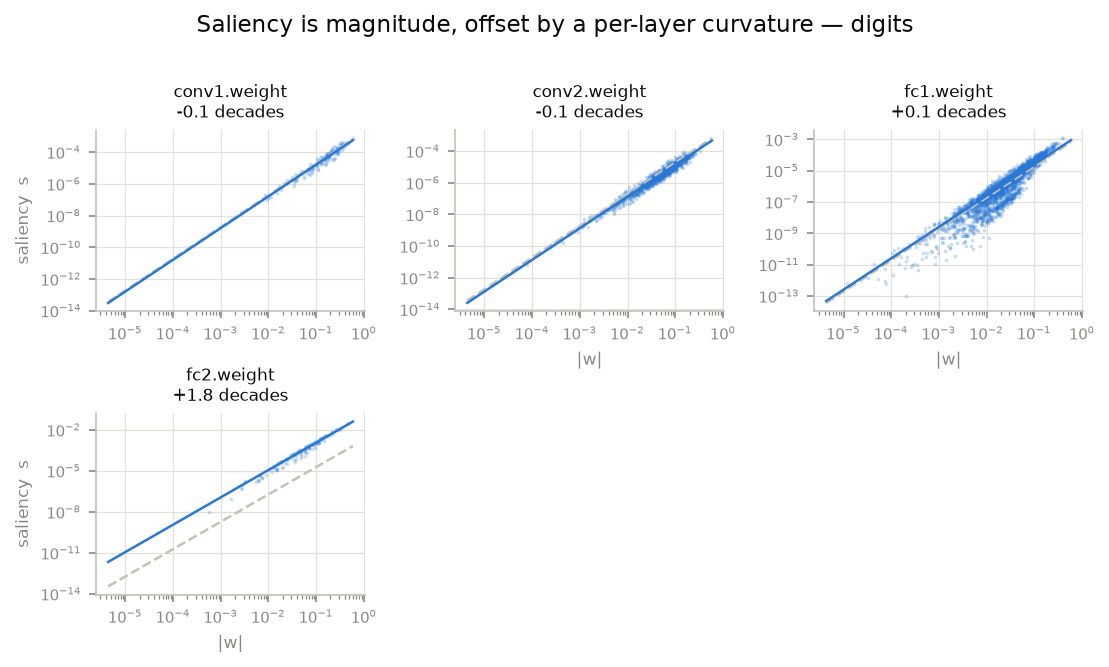

In [20]:
figures.fig6_saliency_vs_magnitude(dr, digits);

In [21]:
if have(dr, "overlap"):
    per = dr["overlap"]["per_layer"]
    note(f"""
**Prediction 2 holds.** **{g['between_layer_frac']:.0%}** of the total variance
in $\\log h$ is accounted for by differences between layer *means*. Within a
layer the two rankings are nearly the same ordering:

{table([(p["name"], f"{p['n']:,}", f"{p['spearman_within']:.3f}",
         f"{p['log_h_std']:.2f}", f"{2 * p['log_w_std']:.2f}") for p in per],
       ("layer", "weights", "Spearman within", "σ_h", "2σ_w"))}

Read the last two columns: wherever $\\sigma_h$ is small against $2\\sigma_w$,
the within-layer Spearman is close to 1 — sorting by saliency inside that layer
*is* sorting by magnitude. The curvature is not per-weight information; it is
one number per layer.
""")

> **Prediction 2 holds.** **35%** of the total variance
> in $\log h$ is accounted for by differences between layer *means*. Within a
> layer the two rankings are nearly the same ordering:
> 
> | layer | weights | Spearman within | σ_h | 2σ_w |
> | --- | --- | --- | --- | --- |
> | conv1.weight | 300 | 0.956 | 0.48 | 2.09 |
> | conv2.weight | 2,400 | 0.976 | 0.41 | 2.28 |
> | fc1.weight | 5,760 | 0.936 | 1.24 | 2.59 |
> | fc2.weight | 300 | 0.986 | 0.41 | 2.62 |
> 
> Read the last two columns: wherever $\sigma_h$ is small against $2\sigma_w$,
> the within-layer Spearman is close to 1 — sorting by saliency inside that layer
> *is* sorting by magnitude. The curvature is not per-weight information; it is
> one number per layer.

### So what does the curvature buy? — prediction 3

If the rankings agree inside every layer, the only place they can disagree is
in how many weights each layer gets to keep. That is what the second-order
information actually purchases: not a better choice of weights, but a better
**budget allocation across layers**.

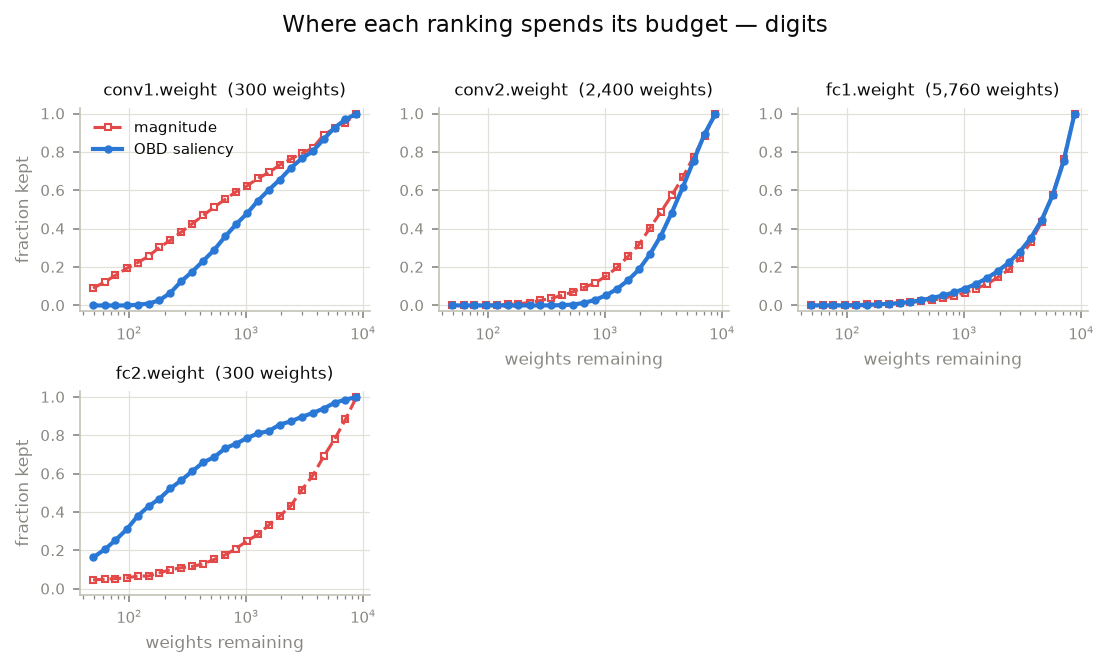

In [22]:
figures.fig7_layer_allocation(dr, digits);

In [23]:
if have(dr, "overlap"):
    level = at(dr["overlap"]["layer_allocation"], dr["overlap"]["n_prunable"] // 20)
    rows = [(name, f"{level['kept_obd'][name] / level['layer_size'][name]:.1%}",
             f"{level['kept_mag'][name] / level['layer_size'][name]:.1%}")
            for name in dr["overlap"]["layers"]]
    note(f"""
**Prediction 3 holds.** At {level['remaining']:,} weights remaining, the two
rankings want very different shapes of network:

{table(rows, ("layer", "kept by OBD", "kept by magnitude"))}

This is the whole difference between the two methods, and it explains a result
from the modern literature that otherwise looks unrelated: *global* magnitude
pruning beats *layerwise* magnitude pruning, and prune-at-init methods
(SNIP/GraSP/SynFlow) turn out to discover good layerwise sparsity **ratios**
rather than good individual masks (Frankle et al. 2021, see References). Both findings say
the same thing this figure does — the per-layer budget is where the information
is.

And it says exactly what the violet curve on Fig 2 was showing. `saliency_layermean`
throws away all within-layer curvature, keeping only $\\bar h_L$ — the layer
budget and nothing else. Where it tracks full OBD, the full diagonal was
redundant.
""")

> **Prediction 3 holds.** At 430 weights remaining, the two
> rankings want very different shapes of network:
> 
> | layer | kept by OBD | kept by magnitude |
> | --- | --- | --- |
> | conv1.weight | 23.3% | 47.0% |
> | conv2.weight | 0.2% | 5.3% |
> | fc1.weight | 2.7% | 2.1% |
> | fc2.weight | 66.0% | 13.0% |
> 
> This is the whole difference between the two methods, and it explains a result
> from the modern literature that otherwise looks unrelated: *global* magnitude
> pruning beats *layerwise* magnitude pruning, and prune-at-init methods
> (SNIP/GraSP/SynFlow) turn out to discover good layerwise sparsity **ratios**
> rather than good individual masks (Frankle et al. 2021, see References). Both findings say
> the same thing this figure does — the per-layer budget is where the information
> is.
> 
> And it says exactly what the violet curve on Fig 2 was showing. `saliency_layermean`
> throws away all within-layer curvature, keeping only $\bar h_L$ — the layer
> budget and nothing else. Where it tracks full OBD, the full diagonal was
> redundant.

### Why magnitude is such a good proxy — prediction 4

The mechanism: at a stationary point of $E + \tfrac{\lambda}{2}\|w\|^2$, the
quadratic model gives $w_k = \frac{h_{kk}}{h_{kk}+\lambda}\,w_k^\ast$. Weight
decay shrinks low-curvature coordinates toward zero and leaves high-curvature
ones alone, so a small weight *becomes* evidence of low curvature —
$\sigma_{hw} > 0$ by construction.

That closes a loop with the second lesson of this reproduction. Weight decay
was already load-bearing for OBD, because without it units saturate and the
curvature collapses to noise. This says it has a second job: the same
regularizer that gives OBD a well-conditioned Hessian is what makes $|w|$ a
usable stand-in for it.

The two presets train at different $\lambda$, so the prediction is directly
checkable.

In [24]:
wd_rows = []
for exp, res in [(digits, dr), (cifar, cr)]:
    if not have(res, "overlap"):
        print(f"missing overlap for {exp.name} — run:\n"
              f"    python3 main.py --dataset {exp.name} --only overlap")
        continue
    s = res["overlap"]["global"]
    wd_rows.append((exp.name, f"{s['weight_decay']:g}", f"{s['cov_log_h_log_w']:+.3f}",
                    f"{s['spearman']:.3f}", f"{s['between_layer_frac']:.0%}"))
if wd_rows:
    display(Markdown(table(wd_rows, ("experiment", "weight decay", "Cov(log h, log|w|)",
                                     "Spearman", "curvature var. between layers"))))

missing overlap for cifar — run:
    python3 main.py --dataset cifar --only overlap


| experiment | weight decay | Cov(log h, log|w|) | Spearman | curvature var. between layers |
| --- | --- | --- | --- | --- |
| digits | 0.001 | +0.422 | 0.927 | 35% |

In [25]:
if len(wd_rows) == 2:
    note(f"""
**Prediction 4.** Compare the covariance column against the weight decay
column. A positive covariance means low-curvature coordinates really are the
small ones — the mechanism above, visible in the data.

Read this alongside §5's result. On CIFAR the magnitude control matched OBD
step for step, and now there's a reason: not that the curvature is uninformative,
but that in an over-parameterized network trained with weight decay the weights
have *already absorbed* the curvature information. Ranking by $|w|$ reads it back
out. OBD's remaining advantage is the cross-layer budget — which is why it
surfaces on digits only in the extreme tail, where getting that budget wrong is
finally fatal.
""")

### What this does and doesn't show

- It is **not** a claim that curvature is useless. It's a claim about *where*
  the diagonal carries information: between layers, not within them.
- The rank-one argument is an approximation. $h_{ij} \approx
  \mathbb{E}[x_j^2]\mathbb{E}[\delta_i^2]$ is exact only when input energy and
  output sensitivity are uncorrelated across samples; `between_layer_frac`
  measures how much slack that leaves, and it isn't 100%.
- It says nothing about methods that use **off-diagonal** curvature. OBS,
  WoodFisher, K-FAC-based pruning and SparseGPT all compensate the surviving
  weights when they delete one, which is information no reweighting of $w^2$
  can reproduce. The decomposition here covers the diagonal only.
- Everything is measured at the trained weights, before any pruning. The
  re-ranked sweeps recompute as they go, and the rankings could diverge further
  once the network is already sparse.

## Appendix

### The results file

`run_experiments` (in `main.py`) *merges* into an existing `results/<name>.json`, and each
experiment is seeded independently, so `--only` can add one experiment to a cached
run. Because merging is exactly how a file ends up holding results from two
different base models, every write stamps `_meta` with the full config, the checkpoint's
SHA-1, the git commit, per-experiment durations and a timestamp, and
`check_meta` warns on the next read if any of them has moved.

```
magnitude, saliency[_recomputed], saliency_layermean[_recomputed],
retrain, retrain_magnitude   [ {remaining, train_loss, test_loss, train_acc, test_acc,
                                (saliency only) predicted_increase, actual_increase}, ... ]
overlap                      {n_prunable, n_dropped_zero, layers, global{...}, per_layer[...],
                              overlap_curve[...], layer_allocation[...], scatter{...}}
_meta                        {config, checkpoint_sha1, git_commit, durations_s, torch, written}
```

### Figures

Pure functions of that JSON, with no torch involved, so plots can be iterated on without
rerunning anything. Each returns `None` when its data is missing. Three colours
carry fixed meanings everywhere: blue = OBD saliency (or "train"), red =
magnitude (or "test"), violet = the layer-mean control. Every series also has its
own marker and line style, so identity never rests on colour alone.

### Extending

To add a third experiment, define a model class and register it in `MODELS`, add an
`Experiment` preset (it registers itself in `EXPERIMENTS`), and add a loader to
`datasets.py`. Everything downstream (training, Hessian, pruning, the overlap
analysis, figures) is already generic over the `Experiment` spec and the model's
layer list.

### Code map

| file | contents |
|---|---|
| [`obd.py`](obd.py) | configs, device selection, models, training, the diagonal Hessian and saliencies, the pruning primitives |
| [`experiments.py`](experiments.py) | the sweeps, the prune-retrain loop, the overlap analysis, the `--only` registry |
| [`figures.py`](figures.py) | every figure, as a pure function of the results JSON |
| [`report.py`](report.py) | the generated tables in `RESULTS.md` and the README; notebook execution |
| [`datasets.py`](datasets.py) | MNIST→16×16 and CIFAR-10 loading |
| [`main.py`](main.py) | the CLI and all disk I/O (`python3 main.py --help`) |
| [`hoeffding.py`](hoeffding.py) | unrelated to the suite: a standalone plot of the Hoeffding bound |

### References

- LeCun, Denker & Solla (1989). *Optimal Brain Damage.* NIPS 2.
- LeCun et al. (1989). *Backpropagation Applied to Handwritten Zip Code Recognition.* Neural Computation 1(4).
- Hassibi & Stork (1992). *Second order derivatives for network pruning: Optimal Brain Surgeon.* NIPS 5.
- Blalock, Gonzalez Ortiz, Frankle & Guttag (2020). *What is the State of Neural Network Pruning?* MLSys.
- Frankle, Dziugaite, Roy & Carbin (2021). *Pruning Neural Networks at Initialization: Why Are We Missing the Mark?* ICLR.